# Imports & Data Load

In [6]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing & modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# Metrics
from sklearn.metrics import r2_score, mean_squared_error

# For residual normality check (optional, if installed)
try:
    from scipy.stats import probplot
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False



In [7]:
os.chdir(r"R:\Data Science Top mentor\Machine Learning\Cohort 127_ML_ Day 37")
df = pd.read_csv('Movie_regression.csv')
df.head()


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400


# Business Understanding

# Data Understanding

In [8]:
print("Shape:",df.shape)
print("\ninfo:")
print(df.info())

print("\nStatistical Summary (numeric):")
display(df.describe())

print("\nStatistical Summery (Categorical):")
display(df.describe(include="object"))

Shape: (506, 18)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors  

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.391498,260.832095,39.181818,545.043478,45057.707510
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.295161,104.779133,12.513697,106.332889,18364.351764
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,10000.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.300000,223.796000,28.000000,465.000000,34050.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,160.000000,254.400000,39.000000,535.500000,42400.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.890000,283.416000,50.000000,614.750000,50000.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,100000.000000



Statistical Summery (Categorical):


,3D_available,Genre
count,506,506
unique,2,4
top,YES,Thriller
freq,279,183


# EDA – Basic & Advanced

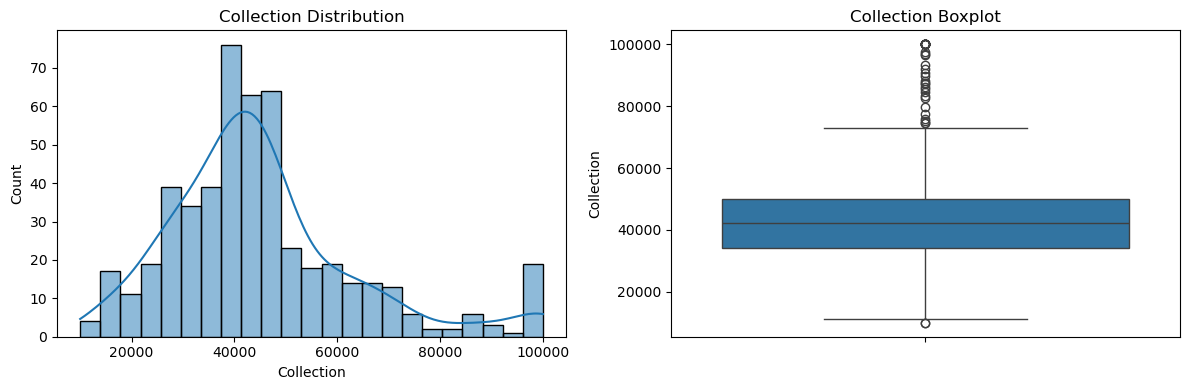

In [9]:
# 4.1 Target Distribution & Outliers
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Collection'],kde = True)
plt.title("Collection Distribution")

plt.subplot(1,2,2)
sns.boxplot(df['Collection'])
plt.title("Collection Boxplot")

plt.tight_layout()
plt.show()

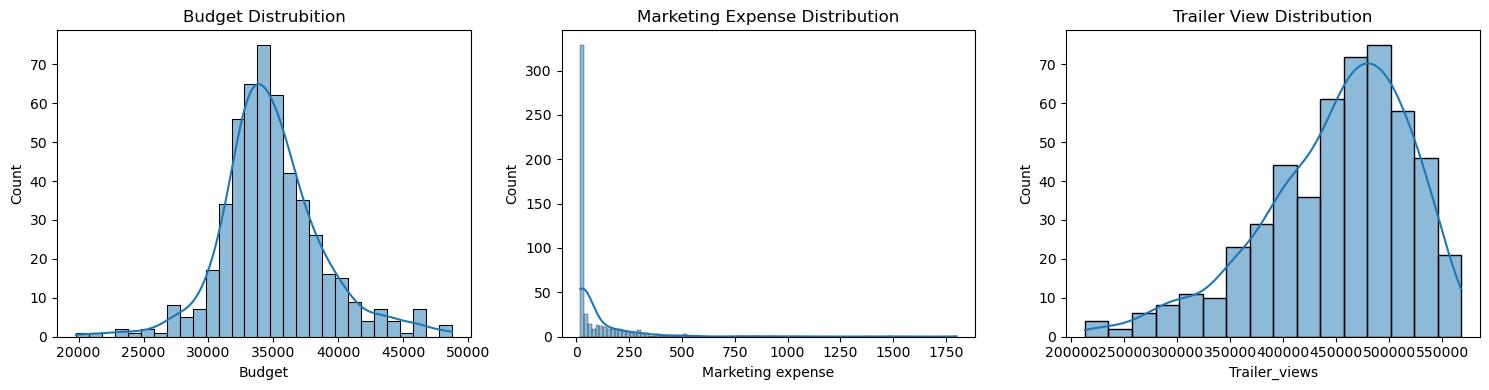

In [10]:
# 4.2 Key Numeric Feature Distributions
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df['Budget'],kde = True)
plt.title("Budget Distrubition")

plt.subplot(1,3,2)
sns.histplot(df['Marketing expense'], kde = True)
plt.title("Marketing Expense Distribution")

plt.subplot(1,3,3)
sns.histplot(df['Trailer_views'],kde = True)
plt.title("Trailer View Distribution")

plt.tight_layout()
plt.show()

In [11]:
# 4.3 Categorical Feature Analysis
print("Genre Counts:")
print(df['Genre'].value_counts())

print('\n3D availability counts:')
print(df['3D_available'].value_counts())

Genre Counts:
Genre
Thriller    183
Comedy      155
Drama        97
Action       71
Name: count, dtype: int64

3D availability counts:
3D_available
YES    279
NO     227
Name: count, dtype: int64


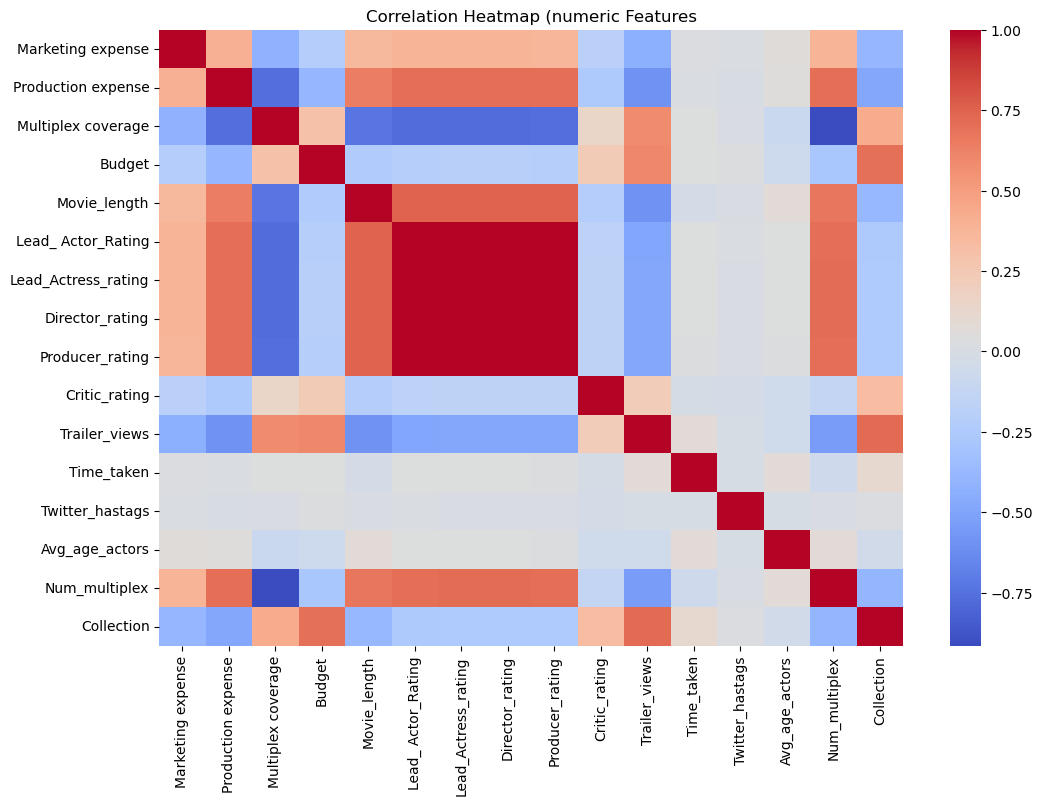

Correlation with collection:


Collection             1.000000
Trailer_views          0.720119
Budget                 0.696304
Multiplex coverage     0.429300
Critic_rating          0.341288
Time_taken             0.111092
Twitter_hastags        0.023122
Avg_age_actors        -0.047426
Director_rating       -0.246650
Producer_rating       -0.248200
Lead_Actress_rating   -0.249459
Lead_ Actor_Rating    -0.251355
Movie_length          -0.377999
Marketing expense     -0.389582
Num_multiplex         -0.391729
Production expense    -0.484754
Name: Collection, dtype: float64

In [12]:
# 4.4 Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot= False, cmap="coolwarm")
plt.title("Correlation Heatmap (numeric Features")
plt.show()

print("Correlation with collection:")
corr['Collection'].sort_values(ascending= False)


# Feature & Target Selection (X and y)

In [13]:
x = df.drop('Collection',axis = 1)
y = df['Collection']

x.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395


# Identify Numeric & Categorical Columns

In [14]:
num_cols = x.select_dtypes(include=["int64","float64"]).columns
cat_cols = x.select_dtypes(include= ["object"]).columns

In [15]:
print(len(num_cols))
print(len(cat_cols))

15
2


# Preprocessing Pipelines (Impute + Encode + Scale)

In [16]:
from sklearn.pipeline import Pipeline

In [17]:
numeric_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_Pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num',numeric_Pipeline,num_cols),
    ('cat',categorical_Pipeline,cat_cols)
])

# Train–Test Split

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)
print("Actual Shape: ",df.shape)
print("X_train Shape: ",x_train.shape)
print("Y_train Shape: ",y_train.shape)
print("X_test Shape: ",x_test.shape)
print("Y_test Shape: ",y_test.shape)

Actual Shape:  (506, 18)
X_train Shape:  (404, 17)
Y_train Shape:  (404,)
X_test Shape:  (102, 17)
Y_test Shape:  (102,)


# Baseline Model – Linear Regression

In [19]:
# 9.1 Training the Model
lr_model = Pipeline([
    ("Preprocessor",preprocessor),
    ("lr",LinearRegression())
])

lr_model.fit(x_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Marketing expense', 'Production expense', 'Multiplex coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['3D_available', 'Genre'], dtype='object'))])),
                ('lr', LinearRegression())])

In [20]:
# 9.2 Evaluation Helper

In [21]:
def evaluate_regression(model,x_train, y_train, x_test, y_test, name = "Model"):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    mse_train = mean_squared_error(y_train,y_train_pred)
    mse_test =  mean_squared_error(y_test,y_test_pred)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    r2_train = r2_score(y_train,y_train_pred)
    r2_test = r2_score(y_test,y_test_pred)

    print(f"==={name} Performance ===")
    print(f"Train R2 : {r2_train:.3f}")
    print(f"Test R2 : {r2_test:.3f}")
    print(f"Train RMSE : {rmse_train:.2f}")
    print(f"Test RMSE : {rmse_test:.2f}")

    return{
        "model": name,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "rmse_train": rmse_train,
        "rmse_test" : rmse_test
    }

lr_results = evaluate_regression(lr_model,x_train,y_train,x_test,y_test,"Linear Regression")

===Linear Regression Performance ===
Train R2 : 0.710
Test R2 : 0.596
Train RMSE : 10011.25
Test RMSE : 10916.50


# Residual Analysis (for Linear Regression)

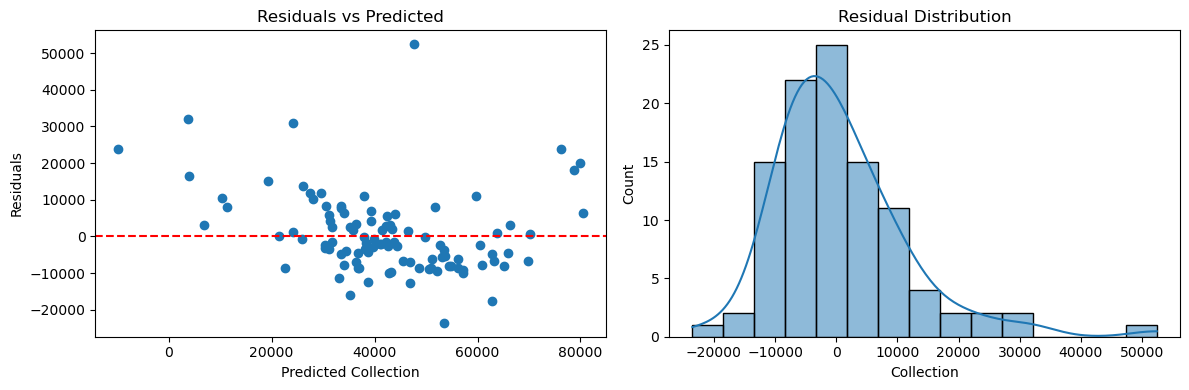

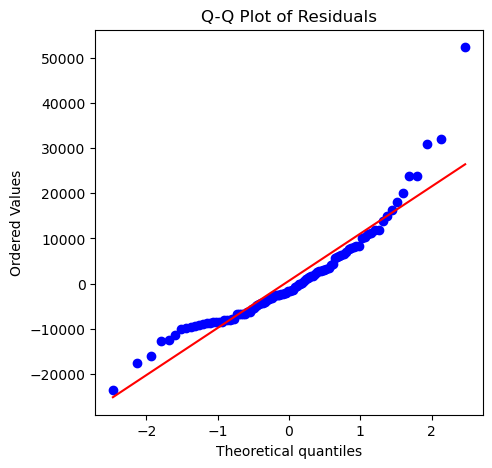

In [22]:
y_test_pred_lr = lr_model.predict(x_test)
residuals = y_test - y_test_pred_lr

plt.figure(figsize=(12,4))

# Residuals vs Predicted
plt.subplot(1,2,1)
plt.scatter(y_test_pred_lr,residuals)
plt.axhline(0,color="red",linestyle ="--")
plt.xlabel("Predicted Collection")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.subplot(1,2,2)
sns.histplot(residuals, kde =True)
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()

if SCIPY_AVAILABLE:
    plt.figure(figsize=(5,5))
    probplot(residuals,dist="norm", plot=plt)
    plt.title("Q-Q Plot of Residuals")
    plt.show()

# Regularized Models – Ridge & Lasso (with Tuning)

In [23]:
ridge_pipeline =Pipeline([
    ("preprocessor",preprocessor),
    ("ridge",Ridge())
])

ridge_params = {
    "ridge__alpha":[0.1,1,5,10,50,100]
}

ridge_grid = GridSearchCV(
    estimator= ridge_pipeline,
    param_grid=ridge_params,
    scoring="r2",
    cv= 5,
    n_jobs =-1
)

ridge_grid.fit(x_train,y_train)
print("Best Ridge alpha : ",ridge_grid.best_params_)
print("Best ridge CV R2 :",ridge_grid.best_score_)

best_ridge = ridge_grid.best_estimator_

ridge_results = evaluate_regression(best_ridge,x_train, y_train, x_test, y_test,"Ridge Regression")

Best Ridge alpha :  {'ridge__alpha': 50}
Best ridge CV R2 : 0.6718875819154355
===Ridge Regression Performance ===
Train R2 : 0.704
Test R2 : 0.617
Train RMSE : 10120.27
Test RMSE : 10624.81


# Lasso Regression + GridSearchCV


In [24]:
lasso_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("lasso", Lasso(max_iter=10000))
])

lasso_params = {
    "lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(x_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best Lasso CV R²:", lasso_grid.best_score_)

best_lasso = lasso_grid.best_estimator_

lasso_results = evaluate_regression(best_lasso, x_train, y_train, x_test, y_test, "Lasso Regression")


Best Lasso alpha: {'lasso__alpha': 1}
Best Lasso CV R²: 0.6645460033963058
===Lasso Regression Performance ===
Train R2 : 0.710
Test R2 : 0.596
Train RMSE : 10011.33
Test RMSE : 10917.63


# Gradient Boosting Regressor

In [25]:
# 12.1 Train GBR Pipeline
gbr_pipeline = Pipeline([
    ("preprocess",preprocessor),
    ("gbr",GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth= 3,
        random_state=42
    ))
])

gbr_pipeline.fit(x_train,y_train)
gbr_result = evaluate_regression(gbr_pipeline, x_train, y_train, x_test, y_test,"Gradient Boosting Regressor")


===Gradient Boosting Regressor Performance ===
Train R2 : 0.989
Test R2 : 0.900
Train RMSE : 1983.96
Test RMSE : 5431.20


In [26]:
#12.2 Model Comparison
result_df = pd.DataFrame([lr_results,ridge_results,lasso_results,gbr_result])
result_df

,model,r2_train,r2_test,rmse_train,rmse_test
0,Linear Regression,0.710005,0.596003,10011.251912,10916.497891
1,Ridge Regression,0.703654,0.617304,10120.272649,10624.809883
2,Lasso Regression,0.710000,0.595919,10011.331285,10917.632930
3,Gradient Boosting Regressor,0.988611,0.899999,1983.963379,5431.203948


# Optional: Feature Importance from Gradient Boosting

In [27]:
# Try to Extract Feature names after preprocessing
feature_names = []
try:
    num_features = list(num_cols)

    ohe = gbr_pipeline.named_steps["preprocess"].named_transformers_['cat'].named_steps["onehot"]
    cat_feature_name = ohe.get_feature_names_out(cat_cols)

    feature_names = list(num_features) + list(cat_feature_name)

    importances = gbr_pipeline.named_steps["gbr"].feature_importances_
    fi_df = pd.DataFrame({
        "Feature":feature_names,
        "Importance": importances
    }).sort_values(by="importance",ascending=False)

    fi_df.head(15)
except Exception as e:
    print("could not compute detailed feature importances (sklearn version issue).")
    print("Error:",e)

could not compute detailed feature importances (sklearn version issue).
Error: 'onehot'


In [28]:
y_pred_lr   = lr_model.predict(x_test)
y_pred_ridge = best_ridge.predict(x_test)
y_pred_lasso = best_lasso.predict(x_test)
y_pred_gbr = gbr_pipeline.predict(x_test)


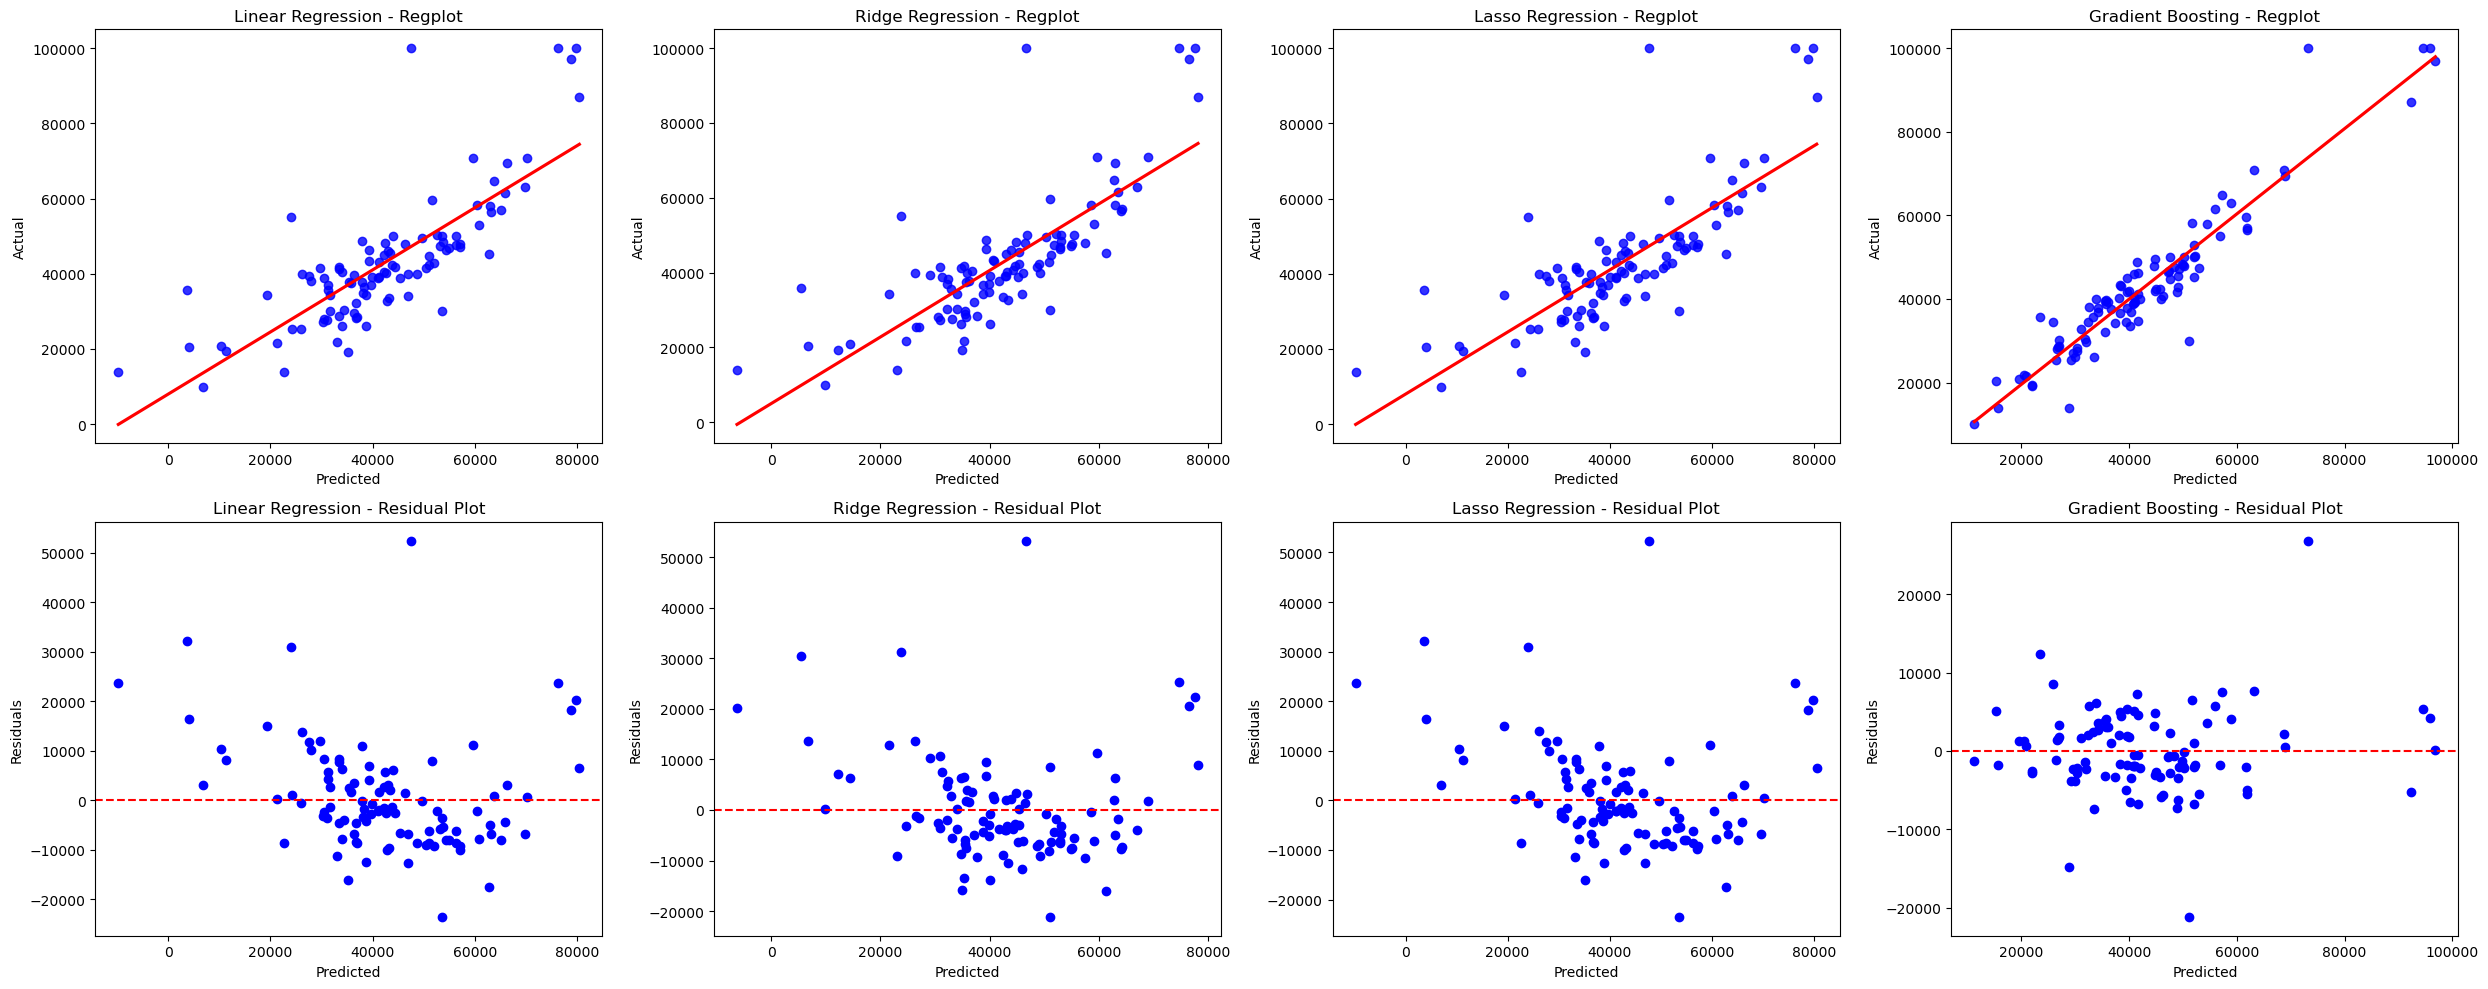

In [29]:
plt.figure(figsize=(25,10))

# -------------------------
# 1. Linear Regression
# -------------------------
plt.subplot(2,4,1)
sns.regplot(
    x=y_pred_lr, y=y_test,
    scatter_kws={"color": "b"},
    line_kws={"color": "r"},
    ci=None
)
plt.title("Linear Regression - Regplot")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(2,4,5)
plt.scatter(y_pred_lr, y_test - y_pred_lr, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Linear Regression - Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

# -------------------------
# 2. Ridge Regression
# -------------------------
plt.subplot(2,4,2)
sns.regplot(
    x=y_pred_ridge, y=y_test,
    scatter_kws={"color": "b"},
    line_kws={"color": "r"},
    ci=None
)
plt.title("Ridge Regression - Regplot")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(2,4,6)
plt.scatter(y_pred_ridge, y_test - y_pred_ridge, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Ridge Regression - Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

# -------------------------
# 3. Lasso Regression
# -------------------------
plt.subplot(2,4,3)
sns.regplot(
    x=y_pred_lasso, y=y_test,
    scatter_kws={"color": "b"},
    line_kws={"color": "r"},
    ci=None
)
plt.title("Lasso Regression - Regplot")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(2,4,7)
plt.scatter(y_pred_lasso, y_test - y_pred_lasso, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Lasso Regression - Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

# -------------------------
# 4. Gradient Boosting Regressor
# -------------------------
plt.subplot(2,4,4)
sns.regplot(
    x=y_pred_gbr, y=y_test,
    scatter_kws={"color": "b"},
    line_kws={"color": "r"},
    ci=None
)
plt.title("Gradient Boosting - Regplot")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(2,4,8)
plt.scatter(y_pred_gbr, y_test - y_pred_gbr, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Gradient Boosting - Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


In [30]:
gbr_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Marketing expense', 'Production expense', 'Multiplex coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['3D_available', 'Genre'], dtype='object'))])),
                ('gbr',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [33]:
new_data = pd.DataFrame({
    "Marketing expense": [20],
    "Production expense": [50],
    "Multiplex coverage": [0.3],
    "Budget": [30000],
    "Movie_length": [150],
    "Lead_ Actor_Rating": [7],
    "Lead_Actress_rating": [7.5],
    "Director_rating": [8],
    "Producer_rating": [8],
    "Critic_rating": [7],
    "Trailer_views": [500000],
    "3D_available": ["YES"],
    "Time_taken": [120],
    "Twitter_hastags": [200],
    "Avg_age_actors": [35],
    "Num_multiplex": [400],
    "Genre": ["Action"]
})

pred = lr_model.predict(new_data)
print("Predicted Collection:", pred[0])


Predicted Collection: 38161.578652287964
